Funcrion for Histogram matching / Histogram Specialization

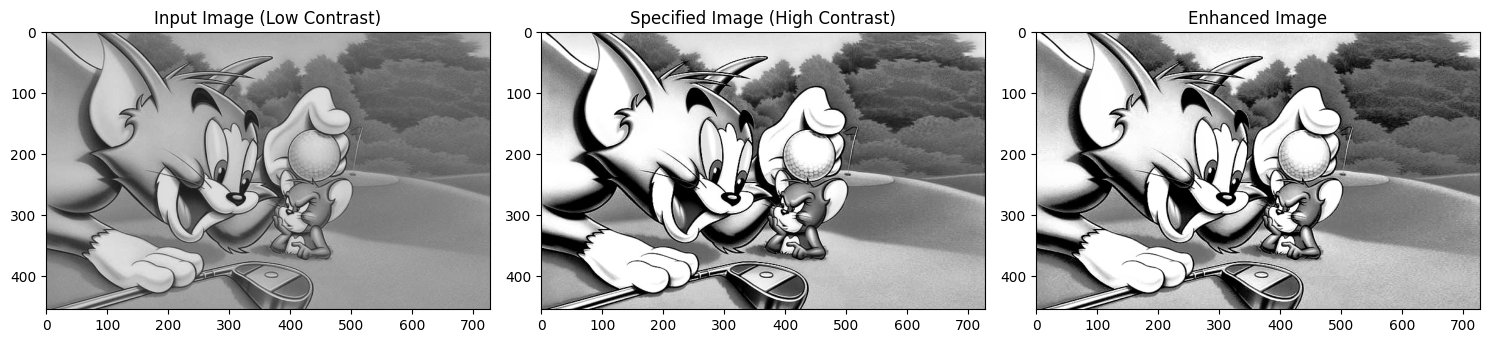

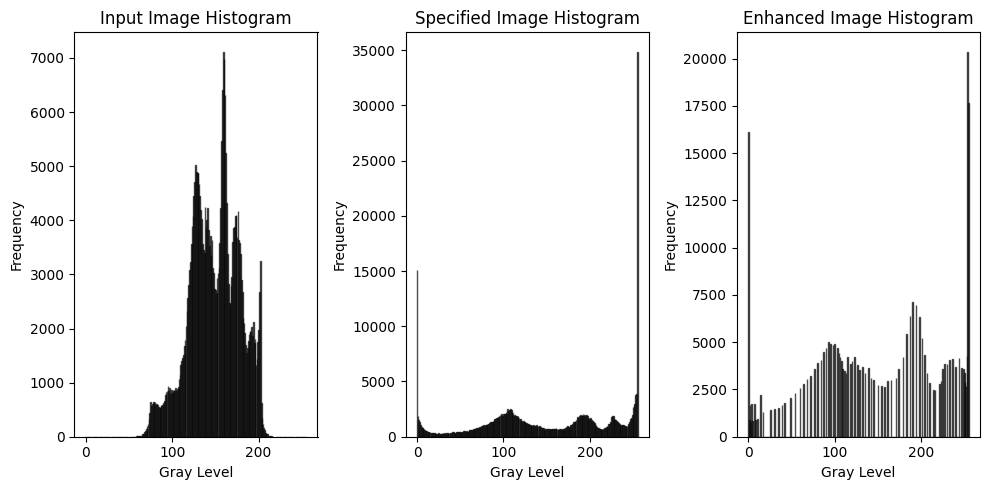

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def calculate_histogram(image, bins):
    # Calculate histogram and CDF
    hist, _= np.histogram(image.flatten(), bins=bins, range=[0, bins-1], density=False)
    pdf = hist / np.sum(hist)
    cdf = np.cumsum(pdf)
    return hist, cdf

def histogram_specification(input_image, specified_image, bins):

    #Calculate the histograms and CDFs for input and specified images
    hist_input, cdf_input= calculate_histogram(input_image, bins)
    hist_specified, cdf_specified= calculate_histogram(specified_image, bins)
    
    #Create the mapping by rounding off the CDFs
    sk_input = np.round((bins - 1) * cdf_input).astype(int)
    sk_specified = np.round((bins-1) * cdf_specified).astype(int)
    
    # Use the mapping logic
    mapping = np.zeros(bins, dtype=np.uint8)  # Mapping array (0-255 for 8-bit image)
    
    for i in range(bins):
        # Find closest match for input pixel intensity to the specified image's CDF
        j = np.argmin(np.abs(sk_specified - sk_input[i]))
        mapping[i] = j
    
    #  Apply the mapping to the input image to create the enhanced image
    enhanced_image = mapping[input_image]
    
    return enhanced_image, hist_input, hist_specified

def plot_histograms(image, hist, title):
    plt.bar(range(len(hist)), hist, color='gray', alpha=0.7, edgecolor='black')
    plt.title(f'{title}')
    plt.xlabel('Gray Level')
    plt.ylabel('Frequency')

# Load the low contrast (A) and high contrast (B) images
input_image = cv2.imread('D:/D.I.P/low_contrast_tomjerry.jpg', cv2.IMREAD_GRAYSCALE)
specified_image = cv2.imread('D:/D.I.P/high_contrast_tomjerry.jpg', cv2.IMREAD_GRAYSCALE)

bins = 256

# Perform histogram specification
enhanced_image, hist_input, hist_specified = histogram_specification(input_image, specified_image, bins)

# Plot the images
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(input_image, cmap='gray')
plt.title("Input Image (Low Contrast)")

plt.subplot(1,3,2)
plt.imshow(specified_image, cmap='gray')
plt.title("Specified Image (High Contrast)")

plt.subplot(1,3,3)
plt.imshow(enhanced_image, cmap='gray')
plt.title("Enhanced Image")

plt.tight_layout()
# plt.show()

# Plot the histograms
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plot_histograms(input_image, hist_input, 'Input Image Histogram')

plt.subplot(1,3,2)
plot_histograms(specified_image, hist_specified, 'Specified Image Histogram')

hist_enhanced,_=calculate_histogram(enhanced_image,bins)
plt.subplot(1,3,3)
plot_histograms(enhanced_image, hist_enhanced, 'Enhanced Image Histogram')

plt.tight_layout()
# plt.show()
